In [3]:
# Cell 1: Imports
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import time
import random

# Reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:
# Cell 2: Data Preparation (Updated for 80/20 Split)
BATCH_SIZE = 128

# Augmentation and normalization for training
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# Only normalization for validation and testing
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# Load full training dataset
full_train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)

# Split into train and validation (80% / 20%)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])
val_dataset.dataset.transform = test_transform

# Loading datasets
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")

100%|██████████| 170M/170M [00:13<00:00, 13.1MB/s]


Training set size: 40000
Validation set size: 10000


In [5]:
# Cell 3: Plain CNN Model
class PlainCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(PlainCNN, self).__init__()
        # Layer 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        # Layer 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)
        # Layer 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)
        # Layer 4
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False)
        self.bn4 = nn.BatchNorm2d(256)
        self.relu4 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)
        # Layer 5
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False)
        self.bn5 = nn.BatchNorm2d(512)
        self.relu5 = nn.ReLU()

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.relu1(self.bn1(self.conv1(x)))
        x = self.pool1(self.relu2(self.bn2(self.conv2(x))))
        x = self.pool2(self.relu3(self.bn3(self.conv3(x))))
        x = self.pool3(self.relu4(self.bn4(self.conv4(x))))
        x = self.relu5(self.bn5(self.conv5(x)))

        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [6]:
# Residual CNN Model
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Shortcut connection handling dimension mismatch
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)
        return out

class ResidualCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(ResidualCNN, self).__init__()
        self.in_channels = 64

        # Initial Layer
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # Residual Blocks
        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)

        # GAP & Classifier
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for s in strides:
            layers.append(ResidualBlock(self.in_channels, out_channels, s))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [7]:
# Cell 5: Training Routine Definition
def train_model(model, name, epochs=15):
    criterion = nn.CrossEntropyLoss()
    # Optimizer & Scheduler constraint: AdamW + OneCycleLR
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    steps_per_epoch = len(train_loader)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-2, steps_per_epoch=steps_per_epoch, epochs=epochs)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print(f"--- Training {name} ---")
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            scheduler.step()

            train_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        epoch_train_loss = train_loss / total
        epoch_train_acc = 100. * correct / total

        # Validation
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

        epoch_val_loss = val_loss / total
        epoch_val_acc = 100. * correct / total

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        overfitting_gap = epoch_train_acc - epoch_val_acc

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {epoch_train_loss:.3f} | Train Acc: {epoch_train_acc:.2f}% | "
              f"Val Loss: {epoch_val_loss:.3f} | Val Acc: {epoch_val_acc:.2f}% | "
              f"Gap: {overfitting_gap:.2f}%")

    total_time = time.time() - start_time
    print(f"Training Time for {name}: {total_time/60:.2f} minutes\n")
    return history

In [8]:
# Cell 6: Run Plain CNN
set_seed(42)
plain_cnn = PlainCNN().to(device)
history_plain = train_model(plain_cnn, "Plain CNN", epochs=15)

--- Training Plain CNN ---
Epoch 1/15 | Train Loss: 1.237 | Train Acc: 55.27% | Val Loss: 1.220 | Val Acc: 57.76% | Gap: -2.48%
Epoch 2/15 | Train Loss: 0.888 | Train Acc: 69.17% | Val Loss: 1.151 | Val Acc: 62.54% | Gap: 6.63%
Epoch 3/15 | Train Loss: 0.729 | Train Acc: 74.58% | Val Loss: 1.136 | Val Acc: 62.12% | Gap: 12.46%
Epoch 4/15 | Train Loss: 0.592 | Train Acc: 79.45% | Val Loss: 0.818 | Val Acc: 72.90% | Gap: 6.55%
Epoch 5/15 | Train Loss: 0.473 | Train Acc: 83.54% | Val Loss: 0.874 | Val Acc: 71.88% | Gap: 11.66%
Epoch 6/15 | Train Loss: 0.357 | Train Acc: 87.61% | Val Loss: 0.672 | Val Acc: 78.91% | Gap: 8.70%
Epoch 7/15 | Train Loss: 0.254 | Train Acc: 91.28% | Val Loss: 0.866 | Val Acc: 75.99% | Gap: 15.30%
Epoch 8/15 | Train Loss: 0.170 | Train Acc: 94.16% | Val Loss: 0.717 | Val Acc: 80.09% | Gap: 14.07%
Epoch 9/15 | Train Loss: 0.089 | Train Acc: 96.98% | Val Loss: 0.846 | Val Acc: 79.73% | Gap: 17.25%
Epoch 10/15 | Train Loss: 0.045 | Train Acc: 98.62% | Val Loss: 0.6

In [9]:
# Cell 7: Run Residual CNN
set_seed(42)
res_cnn = ResidualCNN().to(device)
history_res = train_model(res_cnn, "Residual CNN", epochs=15)

--- Training Residual CNN ---
Epoch 1/15 | Train Loss: 1.323 | Train Acc: 51.39% | Val Loss: 1.233 | Val Acc: 56.63% | Gap: -5.24%
Epoch 2/15 | Train Loss: 0.932 | Train Acc: 67.27% | Val Loss: 1.330 | Val Acc: 56.85% | Gap: 10.41%
Epoch 3/15 | Train Loss: 0.751 | Train Acc: 73.94% | Val Loss: 0.778 | Val Acc: 73.29% | Gap: 0.65%
Epoch 4/15 | Train Loss: 0.604 | Train Acc: 79.23% | Val Loss: 0.761 | Val Acc: 75.17% | Gap: 4.06%
Epoch 5/15 | Train Loss: 0.470 | Train Acc: 83.85% | Val Loss: 0.645 | Val Acc: 78.23% | Gap: 5.62%
Epoch 6/15 | Train Loss: 0.355 | Train Acc: 87.73% | Val Loss: 0.684 | Val Acc: 79.16% | Gap: 8.57%
Epoch 7/15 | Train Loss: 0.260 | Train Acc: 91.04% | Val Loss: 0.528 | Val Acc: 83.22% | Gap: 7.82%
Epoch 8/15 | Train Loss: 0.167 | Train Acc: 94.23% | Val Loss: 0.651 | Val Acc: 81.62% | Gap: 12.61%
Epoch 9/15 | Train Loss: 0.105 | Train Acc: 96.40% | Val Loss: 0.664 | Val Acc: 83.20% | Gap: 13.20%
Epoch 10/15 | Train Loss: 0.048 | Train Acc: 98.33% | Val Loss: 0.

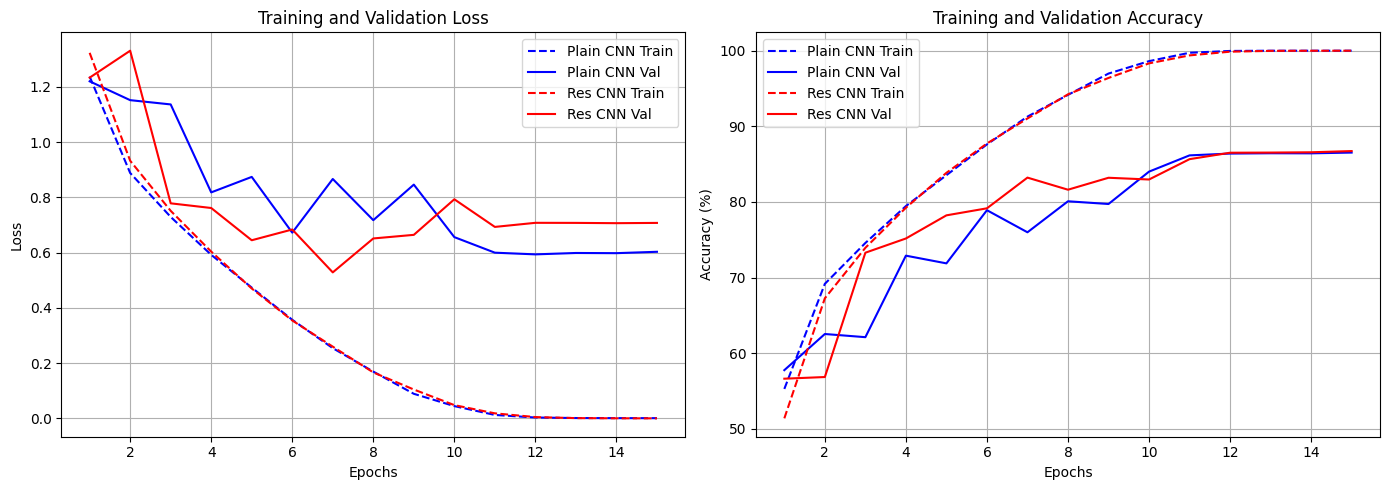

In [10]:
# Cell 8: Plotting Learning Curves
epochs_range = range(1, len(history_plain['train_loss']) + 1)

plt.figure(figsize=(14, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_plain['train_loss'], 'b--', label='Plain CNN Train')
plt.plot(epochs_range, history_plain['val_loss'], 'b-', label='Plain CNN Val')
plt.plot(epochs_range, history_res['train_loss'], 'r--', label='Res CNN Train')
plt.plot(epochs_range, history_res['val_loss'], 'r-', label='Res CNN Val')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_plain['train_acc'], 'b--', label='Plain CNN Train')
plt.plot(epochs_range, history_plain['val_acc'], 'b-', label='Plain CNN Val')
plt.plot(epochs_range, history_res['train_acc'], 'r--', label='Res CNN Train')
plt.plot(epochs_range, history_res['val_acc'], 'r-', label='Res CNN Val')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

--- Classification Report ---
              precision    recall  f1-score   support

       plane      0.849     0.886     0.867      1000
         car      0.925     0.932     0.928      1000
        bird      0.804     0.790     0.797      1000
         cat      0.724     0.732     0.728      1000
        deer      0.832     0.853     0.842      1000
         dog      0.807     0.778     0.792      1000
        frog      0.864     0.886     0.875      1000
       horse      0.907     0.873     0.889      1000
        ship      0.916     0.919     0.918      1000
       truck      0.929     0.905     0.917      1000

    accuracy                          0.855     10000
   macro avg      0.856     0.855     0.855     10000
weighted avg      0.856     0.855     0.855     10000



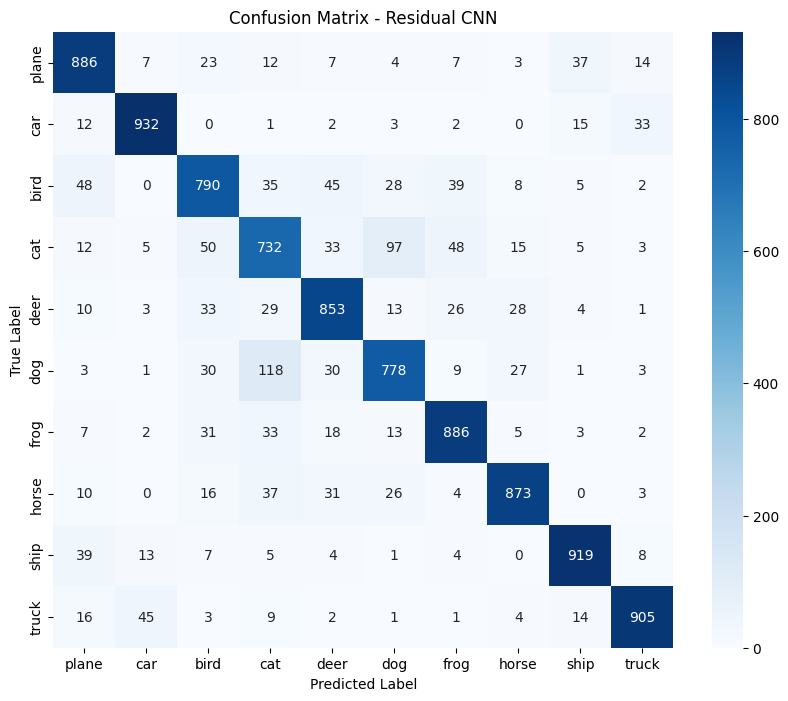

In [11]:
# Cell 9: Test Evaluation & Confusion Matrix
def evaluate_model(model, loader):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.numpy())

    # Classification Report
    print("--- Classification Report ---")
    print(classification_report(all_targets, all_preds, target_names=classes, digits=3))

    # Confusion Matrix
    cm = confusion_matrix(all_targets, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix - Residual CNN')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

evaluate_model(res_cnn, test_loader)

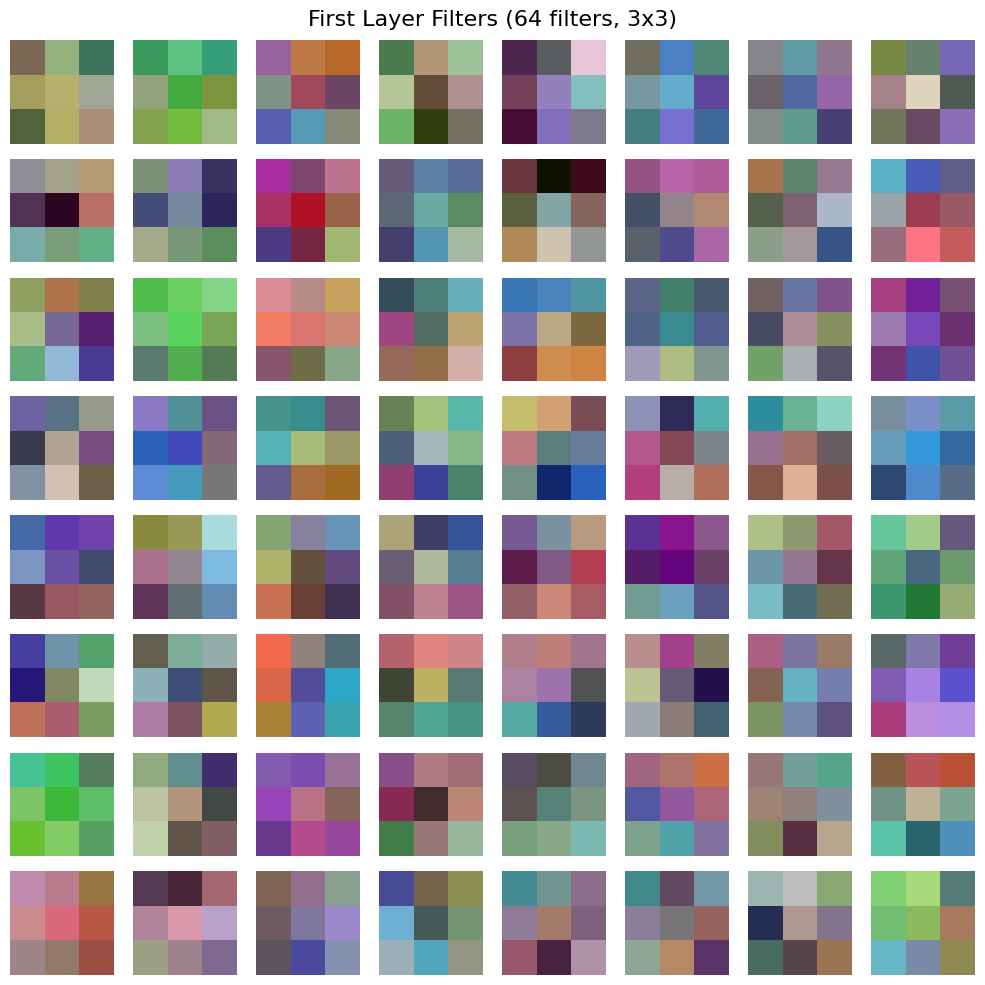

In [12]:
# Cell 10: Visualize First-Layer Filters (8x8 Grid)
# Assuming our first layer is res_cnn.conv1 with 64 filters of size 3x3
weights = res_cnn.conv1.weight.data.cpu()

# Normalize weights for visualization
w_min, w_max = weights.min(), weights.max()
weights = (weights - w_min) / (w_max - w_min)

fig, axes = plt.subplots(8, 8, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    if i < 64:
        # Get filter, convert to numpy, transpose to HxWxC for matplotlib
        img = weights[i].numpy().transpose(1, 2, 0)
        ax.imshow(img)
    ax.axis('off')
plt.suptitle('First Layer Filters (64 filters, 3x3)', fontsize=16)
plt.tight_layout()
plt.show()

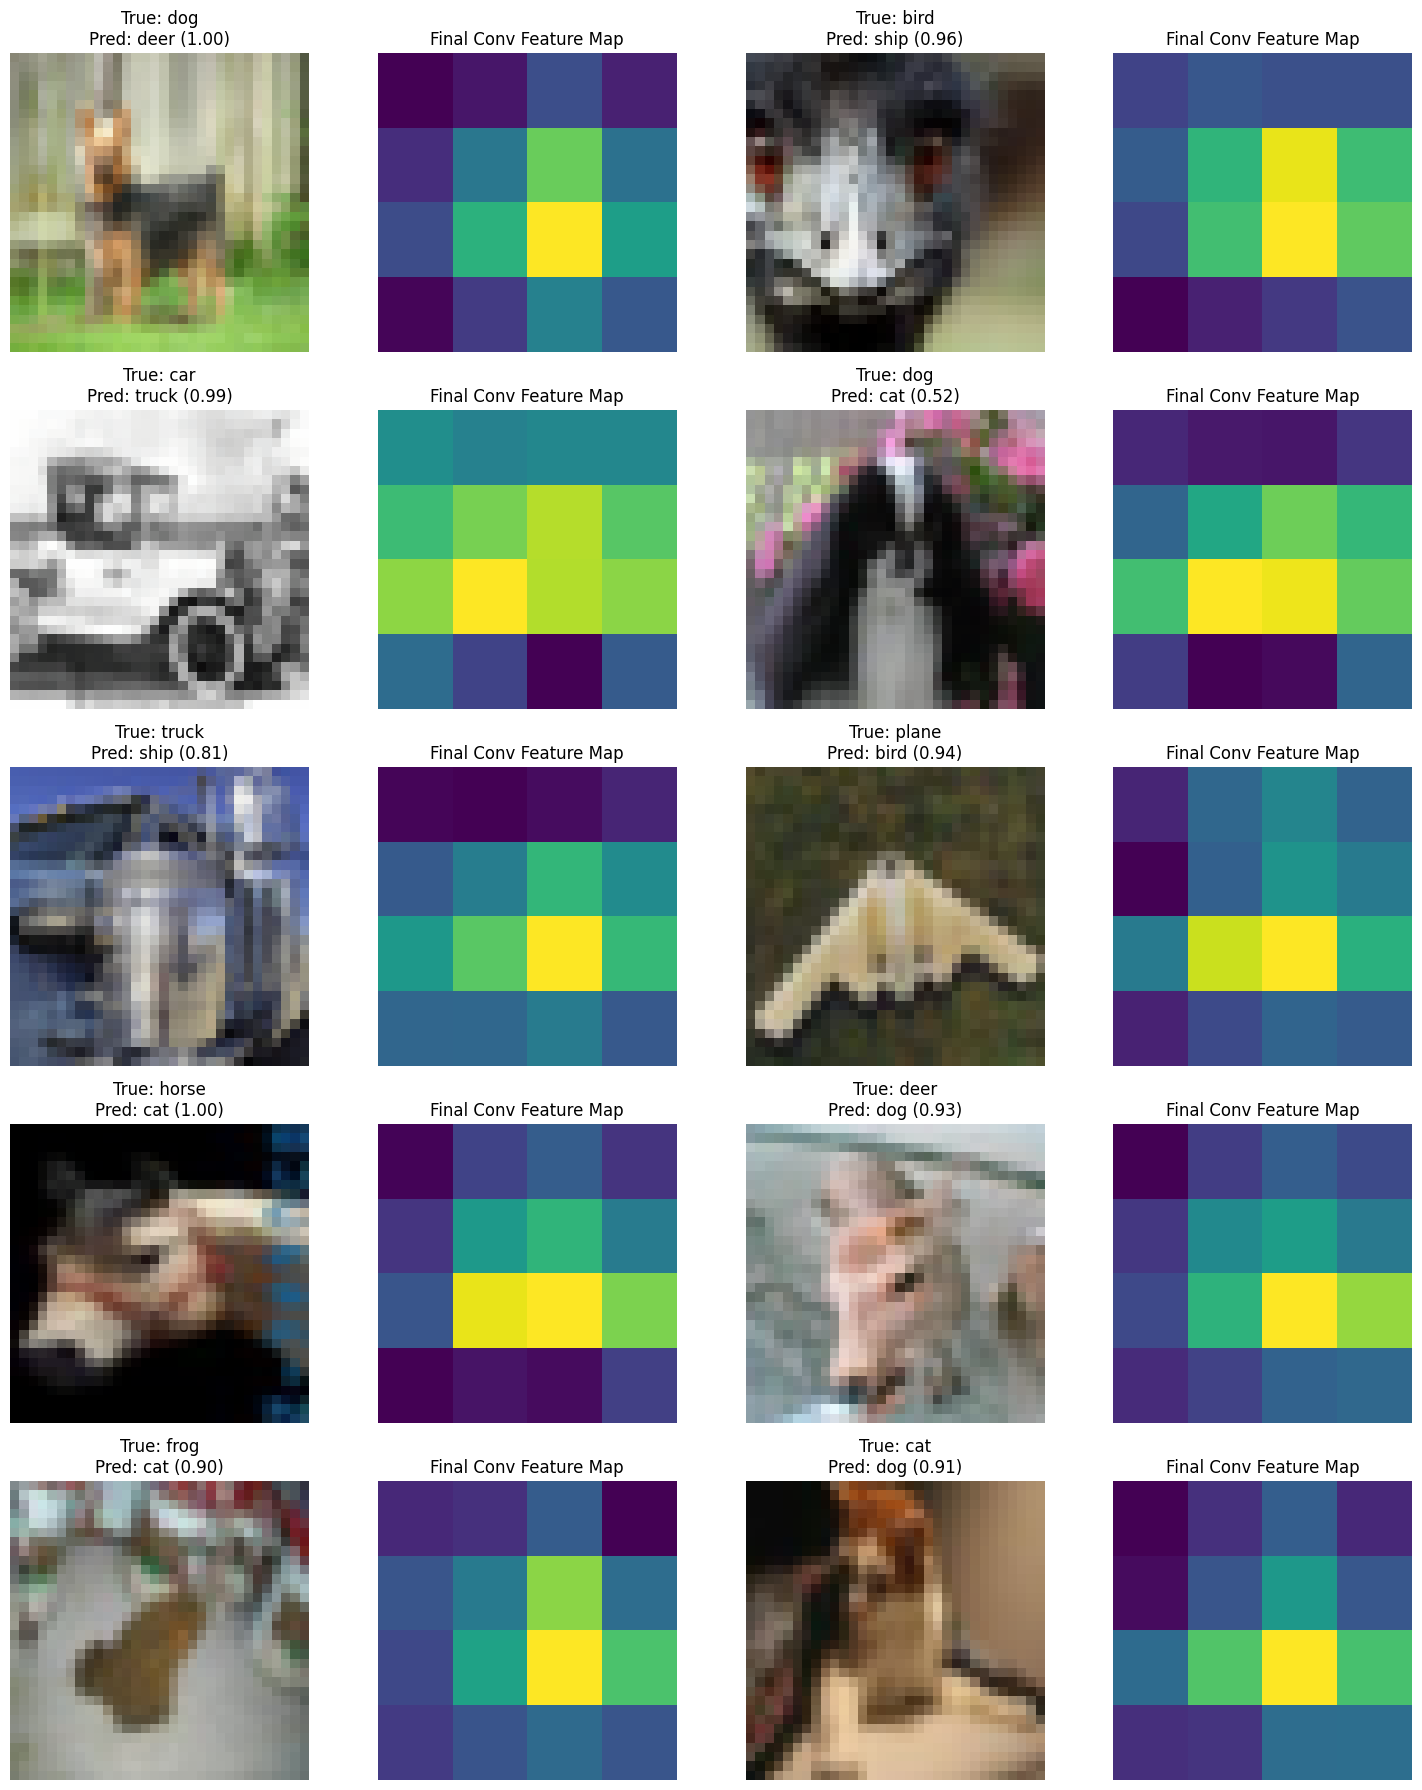

In [13]:
# Cell 11: Misclassifications & Feature Maps
# Hook to get feature maps from the final conv layer
activation = {}
def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

# Attach hook to the final ResidualBlock's last convolution (layer4)
res_cnn.layer4[-1].conv2.register_forward_hook(get_activation('final_conv'))

res_cnn.eval()
misclassified_imgs = []
misclassified_labels = []
misclassified_preds = []
misclassified_confs = []
feature_maps = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs_dev = inputs.to(device)
        outputs = res_cnn(inputs_dev)
        probs = torch.softmax(outputs, dim=1)
        confs, preds = probs.max(1)

        # Find mismatched
        mismatches = preds.cpu() != targets

        if mismatches.any():
            idx = torch.where(mismatches)[0]
            for i in idx:
                if len(misclassified_imgs) < 10:
                    # Un-normalize image for plotting
                    img = inputs[i].numpy()
                    img = (img * np.array([0.2023, 0.1994, 0.2010])[:, None, None]) + np.array([0.4914, 0.4822, 0.4465])[:, None, None]
                    img = np.clip(img.transpose(1, 2, 0), 0, 1)

                    misclassified_imgs.append(img)
                    misclassified_labels.append(classes[targets[i]])
                    misclassified_preds.append(classes[preds[i]])
                    misclassified_confs.append(confs[i].item())

                    # Store mean feature map of the specific image
                    fmap = activation['final_conv'][i].cpu().mean(dim=0).numpy() # average across channels
                    feature_maps.append(fmap)

        if len(misclassified_imgs) >= 10:
            break

# Plot 10 misclassified images with feature maps
fig, axes = plt.subplots(5, 4, figsize=(15, 18))
for i in range(10):
    row, col = i // 2, (i % 2) * 2

    # Original Image
    axes[row, col].imshow(misclassified_imgs[i])
    axes[row, col].set_title(f"True: {misclassified_labels[i]}\nPred: {misclassified_preds[i]} ({misclassified_confs[i]:.2f})")
    axes[row, col].axis('off')

    # Feature Map
    axes[row, col+1].imshow(feature_maps[i], cmap='viridis')
    axes[row, col+1].set_title("Final Conv Feature Map")
    axes[row, col+1].axis('off')

plt.tight_layout()
plt.show()

### Generalization Diagnostics Observations
* **Cat vs. Dog Confusion:** The model often confuses between cats and dogs. The feature maps for these errors often show activations focusing broadly on the animal's face or body outline.
* **Automobile vs. Truck Confusion:** The model also confuses between trucks and automobiles. Errors for it can be seen when the trucks is covered.
* **Background Clutter:** In cases where image blend into blue skies or the background, The feature maps are  disorganized, showing the model failing to isolate the primary subject.

In [14]:
# Cell 13: Calculate FLOPs and Parameters
!pip install torchinfo -q
from torchinfo import summary

def show_model_stats(model, model_name):
    print(f"\n{'='*20} {model_name} Complexity {'='*20}")
    # Using a batch size of 1 and CIFAR-10 input dimensions (3, 32, 32)
    stats = summary(model,
                    input_size=(1, 3, 32, 32),
                    col_names=["input_size", "output_size", "num_params", "mult_adds"],
                    col_width=20,
                    verbose=0)
    print(stats)
    # mult_adds is a common proxy for FLOPs (Multiply-Accumulate operations)

# Show stats for both models
show_model_stats(plain_cnn, "Plain CNN")
show_model_stats(res_cnn, "Residual CNN")


==================== Plain CNN Complexity ====================
Layer (type:depth-idx)                   Input Shape          Output Shape         Param #              Mult-Adds
PlainCNN                                 [1, 3, 32, 32]       [1, 10]              --                   --
├─Conv2d: 1-1                            [1, 3, 32, 32]       [1, 32, 32, 32]      864                  884,736
├─BatchNorm2d: 1-2                       [1, 32, 32, 32]      [1, 32, 32, 32]      64                   64
├─ReLU: 1-3                              [1, 32, 32, 32]      [1, 32, 32, 32]      --                   --
├─Conv2d: 1-4                            [1, 32, 32, 32]      [1, 64, 32, 32]      18,432               18,874,368
├─BatchNorm2d: 1-5                       [1, 64, 32, 32]      [1, 64, 32, 32]      128                  128
├─ReLU: 1-6                              [1, 64, 32, 32]      [1, 64, 32, 32]      --                   --
├─MaxPool2d: 1-7                         [1, 64, 32, 32]   